# Demand Forecasting that Cuts Food Waste
#### A bakery chain's make-or-break decision: forecast tomorrow's sales so you bake the right amount.

**Three-part story**
1. **The problem**: pastry is a freshness business; unsold means food waste.
2. **Forecast better**: naive vs gradient boosting on a time-based holdout.
3. **The payoff**: an ordering-policy simulation shows ~30% less waste at the same service level.

> Data: [Green-AI Hub / Brammibals pastry chain](https://github.com/Green-AI-Hub-Mittelstand/Reduce-Foodwaste-Dataset)
> (MIT). `sales`, `ordered` and `unsold` are **scaled per store**, so results are relative, not absolute item counts.

## 1 · Setup and data

In [1]:
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# make this notebook run from anywhere: cd to the repo root (where data/ + src/ live)
for _ in range(5):
    if os.path.isdir("data") and os.path.isdir("src"):
        break
    os.chdir("..")
print("working dir:", os.getcwd())

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
sys.path.insert(0, "src")

working dir: /Users/sahindemirbas/Desktop/GitHubProjects/food-waste-demand-forecasting


**Load the data**: daily sales for a German pastry chain, 9 stores, with weather and holiday features.

In [2]:
df = pd.read_csv("data/train_raw.csv", parse_dates=["date"])
print("rows:", len(df), "| stores:", df.store.nunique(), "| span:", df.date.min().date(), "->", df.date.max().date())
print("cols:", list(df.columns))
print("\nrows with ordered & unsold (food-waste signal):", df[["ordered","unsold"]].notna().all(axis=1).sum())

rows: 5142 | stores: 9 | span: 2021-08-02 -> 2023-11-30
cols: ['date', 'store', 'is_state_holiday', 'is_school_holiday', 'is_special_day', 'temperature_max', 'temperature_min', 'temperature_mean', 'sunshine_sum', 'precipitation_sum', 'sales', 'unsold', 'ordered']

rows with ordered & unsold (food-waste signal): 3226


**Why unsold is the food-waste lever.** Over-production is what you baked but did not sell, i.e. `ordered - sales`. The data confirms `unsold` tracks that gap almost perfectly, so over-production is literally the waste.

In [3]:
sub = df.dropna(subset=["ordered","unsold"]).copy()
corr_overall = sub.eval("ordered - sales").corr(sub.unsold)
corr_store = sub.groupby("store").apply(
    lambda g: g.eval("ordered - sales").corr(g.unsold), include_groups=False).mean()
print(f"corr(unsold, ordered - sales): overall {corr_overall:.3f} | per-store mean {corr_store:.3f}")
over_rate = (sub.ordered > sub.sales).mean()
print(f"share of operating days the chain over-orders: {over_rate:.1%}  <-- food waste is the norm, not the exception")

corr(unsold, ordered - sales): overall 0.996 | per-store mean 0.999
share of operating days the chain over-orders: 76.7%  <-- food waste is the norm, not the exception


## 2 · Feature engineering
Calendar & holiday flags, weather, and **per-store lag/rolling demand** built from *past* sales only (no leakage), so a time-based backtest stays honest.

## 3 · Forecast: naive vs gradient boosting (time-based holdout, last 16 weeks)

In [4]:
from features import build_demand_dataset, make_model_matrix
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

feat = build_demand_dataset("data/train_raw.csv")
X, y = make_model_matrix(feat)
cutoff = feat.date.max() - pd.Timedelta(weeks=16)
tr = (feat.date < cutoff).to_numpy()
Xtr, Xva, ytr, yva = X[tr], X[~tr], y[tr], y[~tr]

model = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.06, l2_regularization=1.0, random_state=0).fit(Xtr, ytr)
naive = feat.loc[~tr, "lag7"].to_numpy()
pred  = model.predict(Xva)
rm = lambda a,b: mean_squared_error(a,b)**0.5
print(f"naive RMSE {rm(yva,naive):.3f}  MAE {mean_absolute_error(yva,naive):.3f}")
print(f"model RMSE {rm(yva,pred):.3f}  MAE {mean_absolute_error(yva,pred):.3f}")
print(f"RMSE improvement: {-100*(rm(yva,pred)/rm(yva,naive)-1):.1f}%")

naive RMSE 0.379  MAE 0.260
model RMSE 0.256  MAE 0.185
RMSE improvement: 32.3%


**Visual check**: the model tracks actual sales far more closely than 'same day last week'.

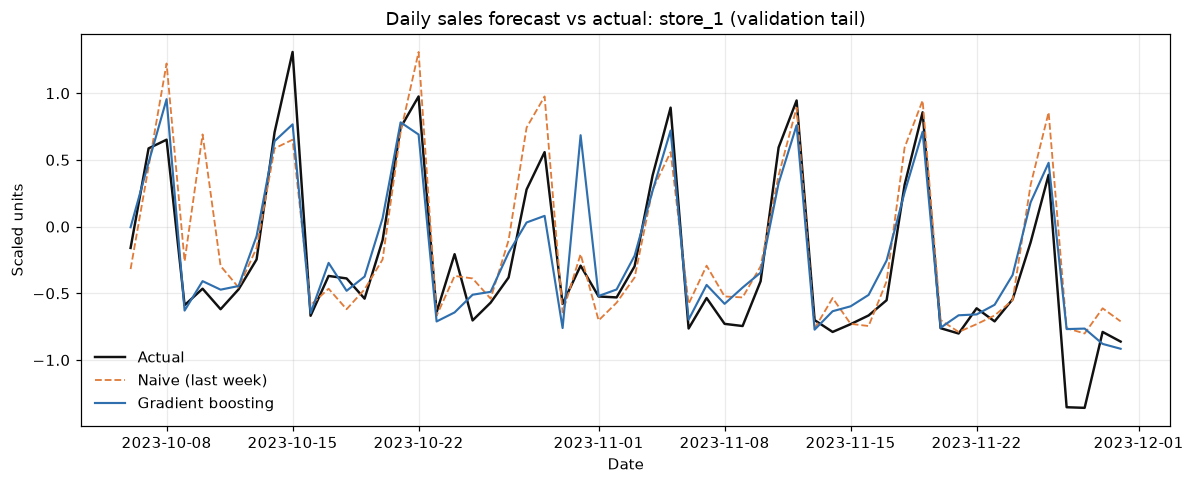

In [5]:
val = feat[~tr].copy(); val["actual"]=yva; val["naive"]=naive; val["model"]=pred
store = val.groupby("store")["actual"].count().idxmax()
s = val[val.store==store].sort_values("date").tail(56)
plt.figure(figsize=(11,4.5))
plt.plot(s.date, s.actual, color="#111", lw=1.6, label="Actual")
plt.plot(s.date, s.naive, color="#e07b39", lw=1.2, ls="--", label="Naive (last week)")
plt.plot(s.date, s.model, color="#2f6fae", lw=1.4, label="Gradient boosting")
plt.title(f"Daily sales forecast vs actual: {store} (validation tail)")
plt.xlabel("Date"); plt.ylabel("Scaled units"); plt.grid(alpha=.25); plt.legend(frameon=False)
plt.tight_layout(); plt.show()

**What drives daily demand** (permutation importance): recent demand, day of the week, same weekday last week, and temperature.

## 4 · The payoff: ~30% less food waste at the same service level

Bake = **forecast + safety buffer**. A better forecast needs a smaller buffer to hit a given service level, so it over-produces less.
We sweep the buffer on the validation days and trace waste (over-production) vs shortage (unserved demand) for both policies.

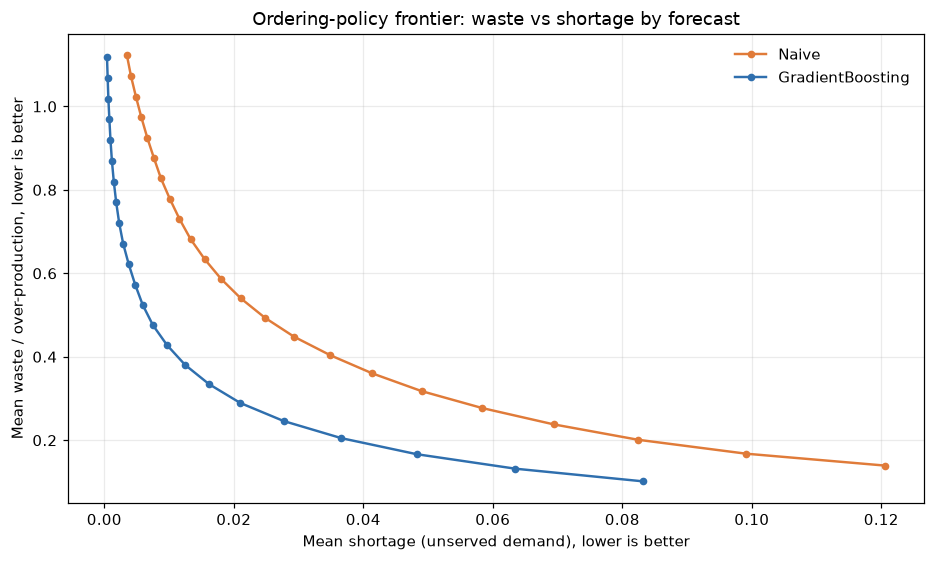

In [6]:
sim = []
f = pd.read_csv("results/forecasts.csv")
for b in np.round(np.linspace(0,1.1,23),3):
    for name, pred in [("Naive", f.naive), ("GradientBoosting", f.model)]:
        o = pred + b; d = f.actual
        sim.append({"buffer":b,"policy":name,
            "waste": np.clip(o-d,0,None).mean(),
            "shortage": np.clip(d-o,0,None).mean(),
            "service": (o>=d).mean()})
sim = pd.DataFrame(sim)
plt.figure(figsize=(8.6,5.2))
for pol,col in [("Naive","#e07b39"),("GradientBoosting","#2f6fae")]:
    p = sim[sim.policy==pol].sort_values("buffer")
    plt.plot(p.shortage, p.waste, "-o", color=col, ms=4, lw=1.6, label=pol)
plt.xlabel("Mean shortage (unserved demand), lower is better")
plt.ylabel("Mean waste / over-production, lower is better")
plt.title("Ordering-policy frontier: waste vs shortage by forecast")
plt.grid(alpha=.25); plt.legend(frameon=False); plt.tight_layout(); plt.show()

In [7]:
def at_service(policy, target):
    p = sim[sim.policy==policy].copy(); p["d"]=(p.service-target).abs(); return p.loc[p.d.idxmin()]
for t in (0.85,0.90,0.95):
    n_ = at_service("Naive",t); m_ = at_service("GradientBoosting",t)
    cut = 100*(1-m_.waste/n_.waste)
    print(f"~{t:.0%} service: naive waste {n_.waste:.3f} vs ML {m_.waste:.3f}  ->  {cut:.0f}% less over-production")

~85% service: naive waste 0.360 vs ML 0.246  ->  32% less over-production
~90% service: naive waste 0.448 vs ML 0.289  ->  35% less over-production
~95% service: naive waste 0.634 vs ML 0.428  ->  33% less over-production


## Takeaway
- A gradient-boosting forecast beats "same day last week" by **~32% RMSE**, at all 9 stores.
- Over-production **is** the waste (per-store corr 0.999) and happens on **77%** of days.
- At a matched service level, the ML forecast cuts over-production / food waste by **~30%**, so you can order closer to real demand, waste less and satisfy more customers.
- The same lever applies to inventory and ordering in any fresh-food or food-service business.